In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded=files.upload()

Saving student.csv to student.csv


In [3]:
import pandas as pd
df=pd.read_csv('student.csv')
print(df.head())

  Student name  Tamil  English  Maths  Physic  Chemistry  computer science  \
0        lingi     98       96     97      96         95                87   
1      bharath     20       23     24      25         27                28   
2         gopi     87       78     98      89         67                76   
3       viszal     98       89     90      70         60                50   
4       karthi     87       76     65      69         76                88   

   Python  Java  
0      90    99  
1      22    23  
2      54    67  
3      65    78  
4      76    74  


In [4]:
subjects = ['Tamil', 'English', 'Maths', 'Physic', 'Chemistry','computer science','Python','Java']

df['Total_Marks'] = df [subjects].sum(axis=1)

df['Average'] = df [subjects].mean(axis=1)

print(df[['Student name', 'Total_Marks', 'Average']])

  Student name  Total_Marks  Average
0        lingi          758   94.750
1      bharath          192   24.000
2         gopi          616   77.000
3       viszal          600   75.000
4       karthi          611   76.375
5       vishnu          616   77.000
6         mani          584   73.000
7       rajesh          618   77.250
8       ananth          159   19.875


In [9]:
weak_students=df[df['Status'] =='Fail']

print("Weak Students")

print(weak_students [['Student name', 'Average']])

Weak Students
  Student name  Average
1      bharath   24.000
8       ananth   19.875


In [7]:
def assign_grade (avg):
 if avg >= 90:
  return 'A+'
 elif avg >= 80:
  return 'A'
 elif avg >= 70:
  return 'B'
 elif avg >= 60:
  return 'C'
 elif avg >= 50:
  return 'D'
 else:
  return 'F'



df['Grade'] =df ['Average'].apply(assign_grade)

df['Status'] =np.where (df ['Average'] >= 50, 'Pass', 'Fail')

print(df[['Student name', 'Average', 'Grade', 'Status']])

  Student name  Average Grade Status
0        lingi   94.750    A+   Pass
1      bharath   24.000     F   Fail
2         gopi   77.000     B   Pass
3       viszal   75.000     B   Pass
4       karthi   76.375     B   Pass
5       vishnu   77.000     B   Pass
6         mani   73.000     B   Pass
7       rajesh   77.250     B   Pass
8       ananth   19.875     F   Fail


In [8]:
topper =df.loc[df['Average'].idxmax()]

print("Top Performer")

print("Name:", topper ['Student name'])

print("Average:", topper ['Average'])

print("Grade:", topper ['Grade'])

Top Performer
Name: lingi
Average: 94.75
Grade: A+


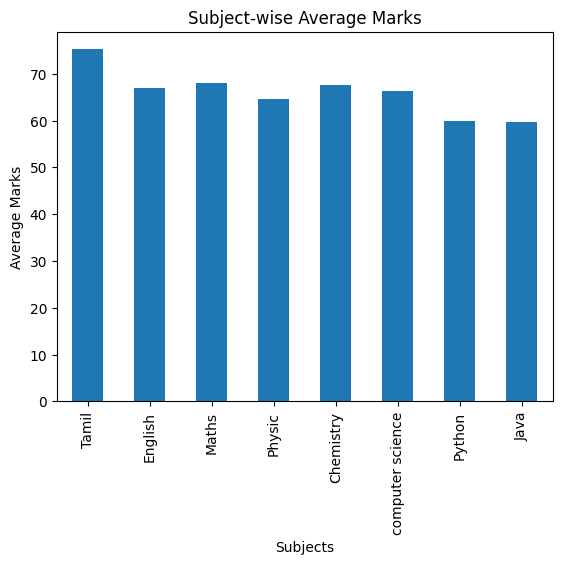

In [10]:
subject_avg=df[['Tamil', 'English', 'Maths','Physic','Chemistry','computer science','Python','Java']].mean()

subject_avg.plot(kind='bar')

plt.title("Subject-wise Average Marks")

plt.xlabel("Subjects")

plt.ylabel("Average Marks")

plt.show()

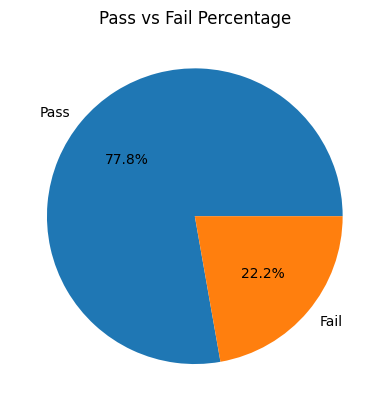

In [11]:
Status_count = df['Status'].value_counts()

plt.pie(Status_count,
        labels=Status_count.index,
        autopct='%1.1f%%')
plt.title("Pass vs Fail Percentage")
plt.show()

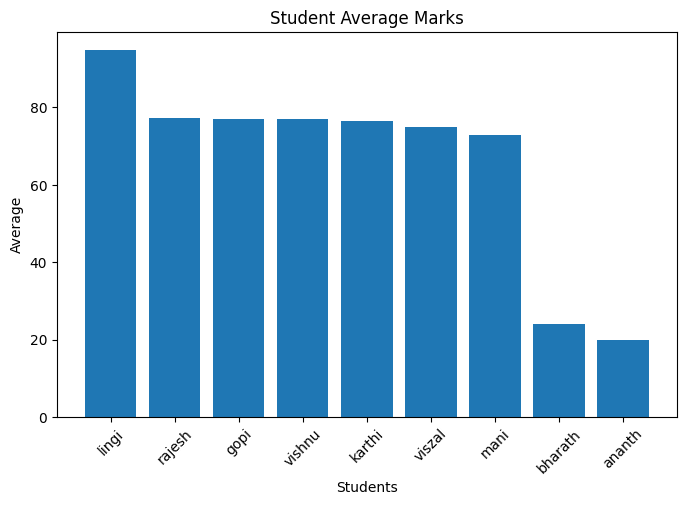

In [12]:
top_students =df.sort_values (by='Average', ascending=False)

plt.figure(figsize=(8,5))

plt.bar(top_students['Student name'],

top_students['Average'])

plt.title("Student Average Marks")

plt.xlabel("Students")

plt.ylabel("Average")

plt.xticks (rotation=45)

plt.show()

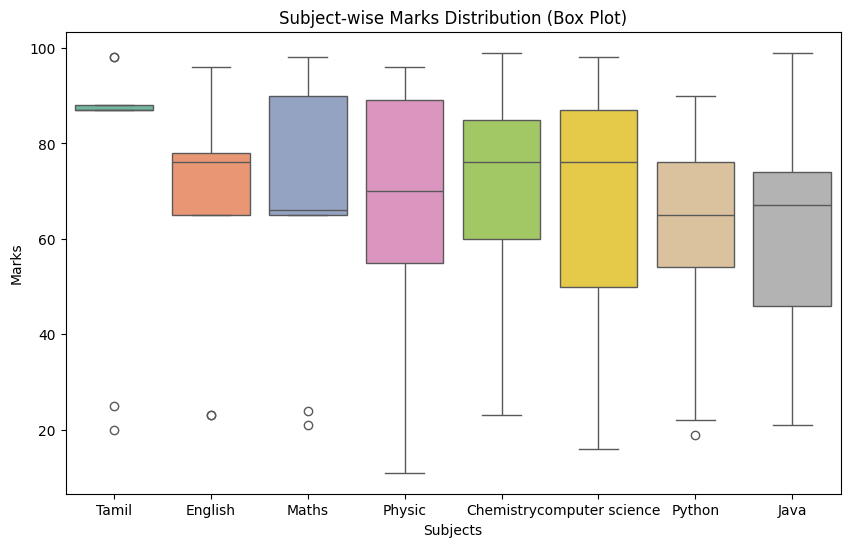

In [13]:
# 3. Box Plot for Subject Marks Distribution
plt.figure(figsize=(10, 6))

# Melting or selecting data so seaborn can plot multiple columns easily
sns.boxplot(data=df[['Tamil', 'English', 'Maths', 'Physic', 'Chemistry','computer science','Python','Java']], palette='Set2')

plt.title('Subject-wise Marks Distribution (Box Plot)')
plt.xlabel('Subjects')
plt.ylabel('Marks')
plt.show()

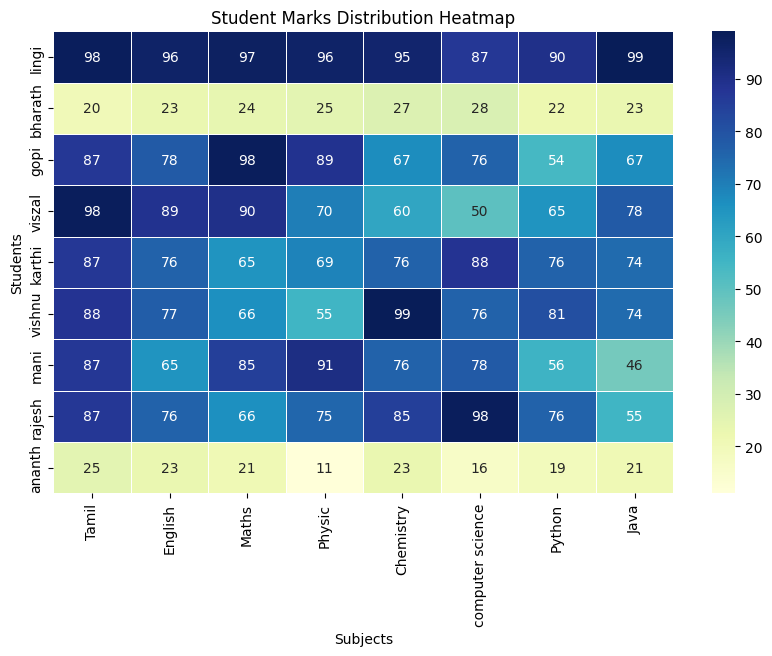

In [14]:
# 2. Student Marks Heatmap
plt.figure(figsize=(10, 6))

# Setting Student_name as the index so it shows on the y-axis
marks_heatmap_df = df.set_index('Student name')[['Tamil', 'English', 'Maths', 'Physic', 'Chemistry','computer science','Python','Java']]

# Generating the heatmap
sns.heatmap(marks_heatmap_df, annot=True, cmap='YlGnBu', fmt="g", linewidths=0.5)

plt.title('Student Marks Distribution Heatmap')
plt.ylabel('Students')
plt.xlabel('Subjects')
plt.show()

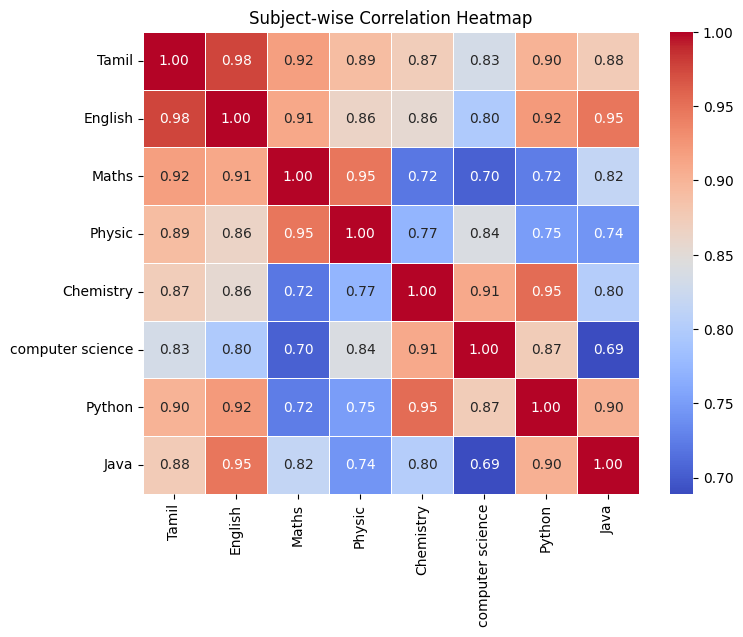

In [15]:
# 1. Correlation Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

# Subsetting only the subject marks columns for correlation
subjects_df = df[['Tamil', 'English', 'Maths','Physic', 'Chemistry','computer science','Python','Java']]
correlation_matrix = subjects_df.corr()

# Generating the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Subject-wise Correlation Heatmap')
plt.show()